# FTCS method for the 1D heat equation

We consider the one-dimensional heat equation

$$
u_t = u_{xx}, \qquad x\in(0,1), \quad t>0,
$$

with homogeneous Dirichlet boundary conditions

$$
u(0,t)=u(1,t)=0,
$$

and initial condition

$$
u(x,0)=\sin(\pi x).
$$

For this problem, the exact solution is

$$
u(x,t)=e^{-\pi^2t}\sin(\pi x).
$$

The objective of this notebook is to implement the Forward-Time
Central-Space (FTCS) method from scratch and study its accuracy and
stability.

## Discretization

Let $x_j = j\,\Delta x$, $t_n = n\,\Delta t$, and $u_j^n \approx u(x_j, t_n)$.
Using a **F**orward difference in **T**ime and a **C**entered difference in **S**pace (**FTCS**),

$$
\frac{u_j^{n+1}-u_j^n}{\Delta t} = \frac{u_{j+1}^n - 2u_j^n + u_{j-1}^n}{\Delta x^2},
$$

which gives the explicit update

$$
u_j^{n+1} = u_j^n + r\,(u_{j+1}^n - 2u_j^n + u_{j-1}^n),
\qquad r = \frac{\Delta t}{\Delta x^2}.
$$

The scheme has order $O(\Delta t) + O(\Delta x^2)$.

## Implementation from scratch

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
nx = 20   # number of space intervals
nt = 100  # number of time steps
T = 0.1   # total time

x = np.linspace(0,1,nx+1)
dx = 1/nx     # space intervals length
dt = T/nt     # time intervals length
r = dt/dx**2  # mesh ratio
print("r = ",r)

r =  0.3999999999999999


In [3]:
u = np.sin(np.pi * x)
u[0] = 0   # boundary conditions
u[-1] = 0

In [4]:
for n in range(nt):   # ftcs loop
    u_new = u.copy()
    for i in range(1,nx):
        u_new[i] = u[i] + r * (u[i+1] - 2*u[i] + u[i-1])
    u = u_new

In [5]:
u_exact = np.exp(-np.pi**2 * T) * np.sin(np.pi * x)   # exact solution

max error =  0.001062511783011033


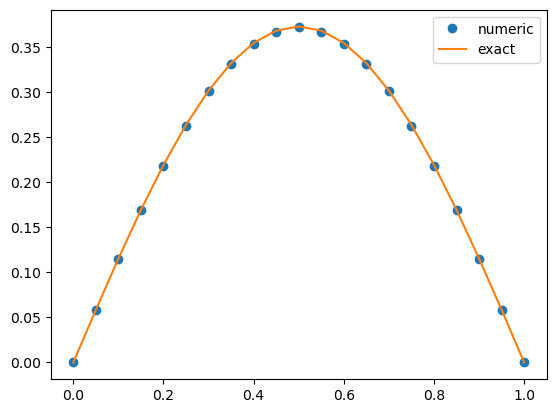

In [6]:
print("max error = ", np.max(np.abs(u - u_exact)))

# max error and graph

plt.plot(x, u, "o", label = "numeric")
plt.plot(x, u_exact, "-", label = "exact")
plt.legend(); plt.show()

## Wrapping the method in a function

In [7]:
def ftcs(nx, nt, T=0.1):
    x = np.linspace(0, 1, nx + 1)
    dx = 1 / nx
    dt = T / nt
    r = dt / dx**2
    u = np.sin(np.pi * x)
    u[0] = u[-1] = 0
    for n in range(nt):
        u_new = u.copy()
        for i in range(1, nx):
            u_new[i] = u[i] + r * (u[i+1] - 2*u[i] + u[i-1])
        u = u_new
    return x, u, r

In [8]:
def exact(x, T=0.1):
    return np.exp(-np.pi**2 * T) * np.sin(np.pi * x)

## Stability experiments

### Stable case: `nx = 20`, `nt = 100` ($r = 0.4$)

error =  0.001062511783011033


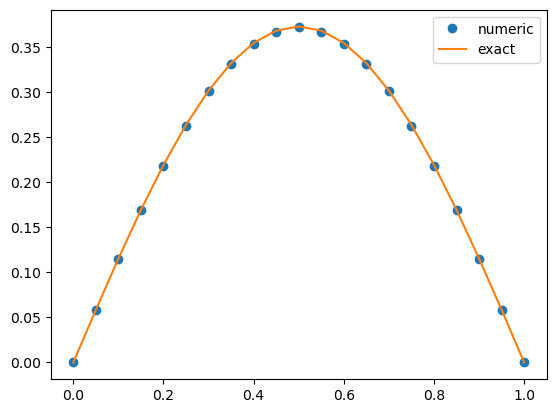

In [9]:
x, u, r = ftcs(nx=20, nt=100)

print("error = ", np.max(np.abs(u - exact(x))))

plt.plot(x, u, "o", label = "numeric")
plt.plot(x, exact(x), "-", label = "exact")
plt.legend(); plt.show()

### Unstable case: `nx = 20`, `nt = 50` ($r = 0.8$)

error =  1.1560365468412717


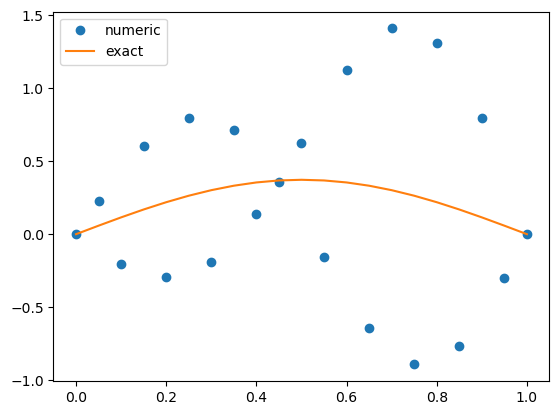

In [10]:
x, u, r = ftcs(nx=20, nt=50)

print("error = ", np.max(np.abs(u - exact(x))))

plt.plot(x, u, "o", label = "numeric")
plt.plot(x, exact(x), "-", label = "exact")
plt.legend(); plt.show()

### Sweeping $r$ with `nx = 40`

In [11]:
nx = 40
for nt in [400, 320, 300, 280, 250, 200]:
    x, u, r = ftcs(nx, nt)
    err = np.max(np.abs(u - exact(x)))
    print(f"nt = {nt:4d}   r = {r:.3f}   error = {err:.3e}")

nt =  400   r = 0.400   error = 2.649e-04
nt =  320   r = 0.500   error = 3.786e-04
nt =  300   r = 0.533   error = 1.806e-01
nt =  280   r = 0.571   error = 5.889e+12
nt =  250   r = 0.640   error = 1.664e+31
nt =  200   r = 0.800   error = 1.944e+51


For `nx = 40`, the error stays around $10^{-4}$ while $r \le 0.5$. Just above that
threshold ($r = 0.533$) it jumps to $\sim 0.18$, and for $r \ge 0.571$ it blows up
($\sim 6 \times 10^{12}$ and beyond). Since $r = \Delta t/\Delta x^2$, keeping $r \le 1/2$ requires `nt` to grow
like `nx`$^2$: the explicit scheme is only conditionally stable.

## Convergence in space

To study the accuracy of the scheme we keep the mesh ratio fixed at
$r = 0.4$ (so the method is stable) and refine the grid, halving
$\Delta x$ each time. Since $r = \Delta t/\Delta x^2$ is constant,
$\Delta t \sim \Delta x^2$, and the time error $O(\Delta t)$ is of the same
size as the space error $O(\Delta x^2)$: the total error should behave like
$O(\Delta x^2)$.

If $E(\Delta x) \approx C\,\Delta x^p$, then halving $\Delta x$ gives

$$
\frac{E(\Delta x)}{E(\Delta x/2)} \approx 2^p
\quad\Longrightarrow\quad
p \approx \log_2\!\left(\frac{E(\Delta x)}{E(\Delta x/2)}\right).
$$

We expect $p \approx 2$, i.e. the error should drop by a factor of 4 each
time we double `nx`.

In [12]:
nxs = [10, 20, 40, 80]
errs = []
for nx in nxs:
    nt = nx**2 // 4          # keeps r = 0.4 (with T = 0.1)
    x, u, r = ftcs(nx, nt)
    errs.append(np.max(np.abs(u - exact(x))))
    print(f"nx = {nx:3d}   nt = {nt:5d}   r = {r:.3f}   error = {errs[-1]:.3e}")

for k in range(1, len(errs)):
    ratio = errs[k-1] / errs[k]
    print(f"nx {nxs[k-1]} -> {nxs[k]}:  ratio = {ratio:.2f}   order = {np.log2(ratio):.2f}")

nx =  10   nt =    25   r = 0.400   error = 4.294e-03
nx =  20   nt =   100   r = 0.400   error = 1.063e-03
nx =  40   nt =   400   r = 0.400   error = 2.649e-04
nx =  80   nt =  1600   r = 0.400   error = 6.620e-05
nx 10 -> 20:  ratio = 4.04   order = 2.01
nx 20 -> 40:  ratio = 4.01   order = 2.00
nx 40 -> 80:  ratio = 4.00   order = 2.00


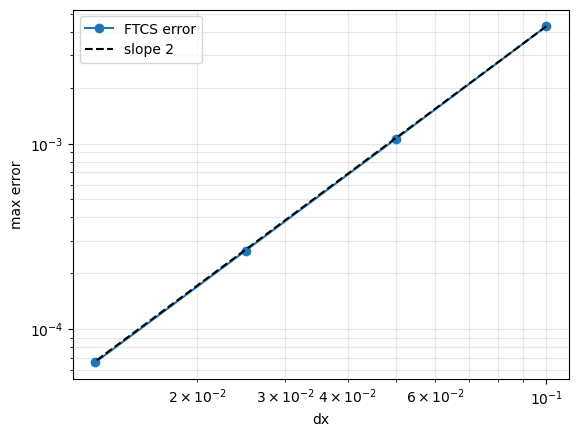

In [13]:
h = 1 / np.array(nxs)
plt.loglog(h, errs, "o-", label="FTCS error")
plt.loglog(h, errs[0] * (h / h[0])**2, "k--", label="slope 2")
plt.xlabel("dx"); plt.ylabel("max error")
plt.legend(); plt.grid(True, which="both", alpha=0.3); plt.show()

The error decreases by a factor of about 4 each time `nx` doubles, and the
observed order is $p \approx 2.00$. This confirms that, with $r$ fixed, the
FTCS scheme is second-order accurate in $\Delta x$.